In [8]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
from scipy.stats import pearsonr, zscore, kurtosis, shapiro
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression


df = pd.read_csv("data/advertising_and_sales.csv", index_col="id")

display(Markdown("### Descripción estadística"))
display(df.describe())
display(Markdown("-" * 80))
display(Markdown("### Vista previa del histórico"))
display(df.head(10))

### Descripción estadística

,tv,radio,social_media,sales
count,4500.000000,4500.000000,4500.000000,4500.000000
mean,54903.547138,18321.505844,3335.742613,72727.553899
std,30135.928474,11628.678497,2211.899475,38195.621991
min,33.970000,0.440000,0.030000,7666.685000
25%,30478.517500,9286.802500,1539.770000,40882.740000
50%,52026.315000,16297.640000,3070.610000,68635.567500
75%,75761.262500,25691.567500,4812.652500,99192.781250
max,150940.950000,71122.910000,13981.660000,180079.915000


--------------------------------------------------------------------------------

### Vista previa del histórico

,tv,radio,social_media,influencer,sales
id,,,,,
0,11124.31,6906.88,2907.98,Mega,26258.295
1,102.79,12676.45,2409.57,Mega,11709.120
2,45774.58,14914.53,2913.41,Mega,48345.630
3,65232.46,32016.26,6922.30,Mega,143851.565
4,11376.10,5490.95,1406.00,Micro,16816.820
5,40583.98,11999.30,1027.16,Mega,51321.760
6,54064.46,14125.79,4273.60,Micro,69624.320
7,30221.43,14291.12,2289.85,Nano,26573.295
8,60356.57,28263.00,7130.12,Macro,76668.675


#### Análisis Descriptivo: descartar y adoptar factores
Como base analítica, a continuación se realiza una visuliazación de análisis multivariable (relacionando valores continuos y categorías), de manera que se puedan extraer resultados a primera vista:
- Hay un claro incremento monetario lineal conforme aumenta el presupuesto en la variable TV
- Hay evidencia visual de heterocedasticidad, es decir, a mayor inversión mayor variabilidad en ventas
- La jerarquía de la variable Influencer es completamente volátil en la dispersión de los datos

--------------------------------------------------------------------------------

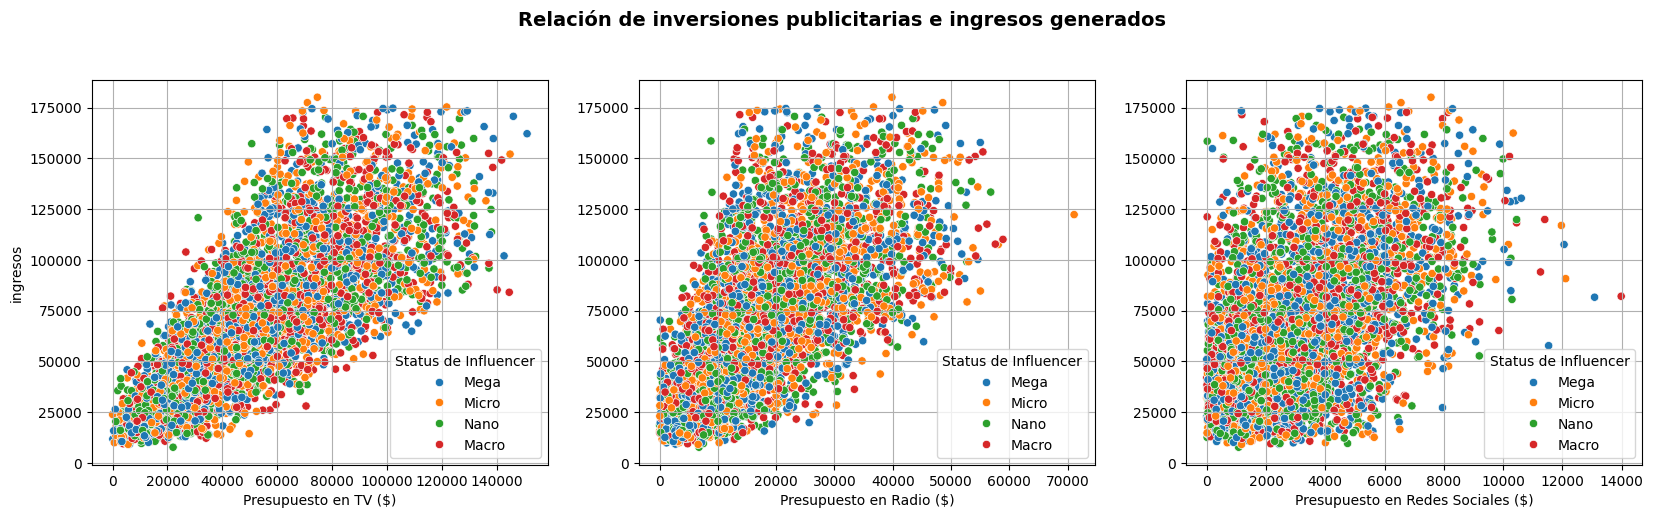

In [24]:
fig, ax = plt.subplots(1,3, figsize=(20,5))

sns.scatterplot(data=df, x="tv", y="sales", hue="influencer", ax=ax[0])
ax[0].grid("on")
ax[0].set_xlabel("Presupuesto en TV ($)")
ax[0].set_ylabel("Ingresos ($)")
ax[0].legend(title="Status de Influencer")

sns.scatterplot(data=df, x="radio", y="sales", hue="influencer", ax=ax[1])
ax[1].grid("on")
ax[1].set_xlabel("Presupuesto en Radio ($)")
ax[1].set_ylabel("")
ax[1].legend(title="Status de Influencer")

sns.scatterplot(data=df, x="social_media", y="sales", hue="influencer", ax=ax[2])
ax[2].grid("on")
ax[2].set_xlabel("Presupuesto en Redes Sociales ($)")
ax[2].set_ylabel("")
ax[2].legend(title="Status de Influencer")

display(Markdown("""#### Análisis Descriptivo: descartar y adoptar factores
Como base analítica, a continuación se realiza una visuliazación de análisis multivariable (relacionando valores continuos y categorías), de manera que se puedan extraer resultados a primera vista:
- Hay un claro incremento monetario lineal conforme aumenta el presupuesto en la variable TV
- Hay evidencia visual de heterocedasticidad, es decir, a mayor inversión mayor variabilidad en ventas
- La jerarquía de la variable Influencer es completamente volátil en la dispersión de los datos"""))
display(Markdown("-" * 80))


fig.suptitle("Relación de inversiones publicitarias e ingresos generados", fontsize=14, fontweight="bold", y=1.02)
plt.subplots_adjust(wspace=0.2)
plt.show()

#### Análisis Exploratorio de Datos: determinar patrones e hipótesis

Seguidamente se explorará el comportamiento de los datos donde el objetivo es descubrir patrones, relaciones y estructuras que guíen la implementación de un modelo particular como solución. En un caso de regresión lineal con resultados fiables, se deben cumplir los siguientes supuestos fundamentales:

**Linealidad**: La relación entre la variable independiente (X) y la variable dependiente (Y) debe ser lineal. Esto significa que el cambio en (Y) por cada unidad de cambio en (X) es constante.

**Independicia y normalidad**: Para propósitos de inferencia (pruebas de hipótesis y cálculos de intervalos de confianza), los residuos del modelo deben seguir una distribución normal con media cero (se anulan entre si).

**Ausencia de outliers**: No es estrictamente un supuesto teórico sino más bien un requisito práctico de diagnóstico. Los datos no deben contener valores extremos influyentes que distorsionen significativamente la pendiente de la línea de regresión.

In [9]:
corr_tv, _ = pearsonr(df["tv"], df["sales"])
corr_radio, _ = pearsonr(df["radio"], df["sales"])

df_zscore = df.loc[:, ["tv","radio"]]

df_zscore["tv_zscore"] = abs(zscore(df["tv"]))
df_zscore["radio_zscore"] = abs(zscore(df["radio"]))

outliers_tv = df_zscore.loc[df_zscore["tv_zscore"] > 3, "tv_zscore"].shape[0]
outliers_radio = df_zscore.loc[df_zscore["radio_zscore"] > 3, "radio_zscore"].shape[0]

curtosis_tv = kurtosis(df["tv"])
curtosis_radio = kurtosis(df["radio"])

data = {
   "TV": [round(corr_tv,2), outliers_tv, round(curtosis_tv,1)],
   "Radio": [round(corr_radio,2), outliers_radio, round(curtosis_radio,1)]
}

df_measures  = pd.DataFrame(data, index=["𝑟 (sales)", "outliers", "curtosis"])

display(Markdown("### Métricas estadísticas"))
display(df_measures)

### Métricas estadísticas

,TV,Radio
𝑟 (sales),0.77,0.65
outliers,2.00,16.00
curtosis,-0.50,0.00


#### Linear Regression: modelado sesgado por mayor rentabilidad
Antes de proceder con el desarrollo e implementación del simulador estratégico de reasignación de presupuesto publicitario —diseñado para proyectar el impacto económico en los ingresos y el Retorno de Inversión (ROI)—, se ejecutará una fase preliminar de validación estocástica. El objetivo principal es probar la viabilidad del pipeline de datos utilizando un Modelo de Regresión Lineal Simple de base. Este modelo actuará como benchmark inicial y estará intencionalmente sesgado bajo una hipótesis de optimización heurística: evaluar el comportamiento del sistema ante un escenario teórico que asume un incremento del 12% en el ROI histórico.

Para aislar el efecto del canal publicitario de mayor impacto histórico y reducir el ruido en esta fase beta, el modelo matemático se acotará a la interacción de dos variables continuas específicas:
*   Variable Independiente ($X$): Inversión económica en publicidad de Televisión (TV Costs).
*   Variable Dependiente ($Y$): Ingresos brutos generados por ventas (Sales Revenues).

Donde el coeficiente $\beta_1$ de la ecuación incorporará directamente el factor de sesgo controlado del +12% sobre la pendiente histórica promedio, permitiendo simular el estrés del modelo ante este cambio en las condiciones económicas antes de escalar la arquitectura de software.

In [23]:
df["ROI"] = (df["sales"] - df["tv"]) / df["tv"]
df_efficient = df[df["ROI"] >= df["ROI"].quantile(0.12)]

index = np.arange(len(df_efficient))
np.random.seed(42)
np.random.shuffle(index)

X = df_efficient["tv"].values.reshape((-1, 1))[index]
y = df_efficient["sales"].values[index]

limit = int(0.8 * len(X))

X_train, X_test = X[:limit], X[limit:]
y_train, y_test = y[:limit], y[limit:]

model_linear_regression = LinearRegression()
model_linear_regression.fit(X_train, y_train)

y_pred_test = model_linear_regression.predict(X_test)
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

residuals = y_test - y_pred_test
stat, p_val = shapiro(residuals)
norm_residuals = p_val > 0.05

display(Markdown("#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---"))
print(f"Coeficiente de Determinación (R²): {round(r2, 4)}")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${round(rmse, 2)}")
print(f"Normalidad de Residuos (Shapiro-Wilk): p-valor = {p_val:.4e} -> {"PASÓ" if norm_residuals else "FALLÓ"}")
print("-" * 100)
print(f"Interpretación: El modelo explica el {round(r2*100, 2)}% de la variación en ventas.")
if r2 > 0.55 and norm_residuals:
    print("Estado: MODELO VALIDADO PARA PRODUCCIÓN (EXCELENTE) - Alta precisión y residuos normales pero sin homocedasticidad.")
elif r2 > 0.55 and not norm_residuals:
    print("Estado: MODELO VALIDADO PARA PRODUCCIÓN (APROBADO) - Alta precisión pero residuos no normales y sin homocedasticidad.")
else:
    print("Estado: REVISAR SEGMENTACIÓN - Precisión por debajo del umbral objetivo.")

#### --- RESULTADOS DE VALIDACIÓN DEL MODELO ---

Coeficiente de Determinación (R²): 0.6877
Raíz del Error Cuadrático Medio (RMSE): $21240.68
Normalidad de Residuos (Shapiro-Wilk): p-valor = 7.4116e-16 -> FALLÓ
----------------------------------------------------------------------------------------------------
Interpretación: El modelo explica el 68.77% de la variación en ventas.
Estado: MODELO VALIDADO PARA PRODUCCIÓN (APROBADO) - Alta precisión pero residuos no normales y sin homocedasticidad.


#### Herramienta interactiva de optimización estratégica basado en la frontera de eficiencia presupuestaria

In [ ]:
def get_elasticities(data):
    df_log = np.log(data[["tv", "radio", "social_media", "sales"]] + 1)
    model = LinearRegression()
    model.fit(df_log[["tv", "radio", "social_media"]], df_log["sales"])
    return dict(zip(["TV", "Radio", "Social Media"], model.coef_))

elasticities = get_elasticities(df)
mean_margin = df["sales"].mean() - (df["tv"].mean() + df["radio"].mean() + df["social_media"].mean())

app = dash.Dash(__name__)

app.layout = html.Div(id="body", className="e2_body", children=[
    html.H1("Estrategia de Inversión: del volumen a la rentabilidad", className="e2_title"),

    html.Div(className="e2_div_stats", children=[
        html.Div([html.H3("Margen Neto Promedio"), html.P(f"${round(mean_margin, 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
        html.Div([html.H3("Elasticidad TV (Dominancia)"), html.P(f"{round(elasticities["TV"], 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
        html.Div([html.H3("Elasticidad Radio (Oportunidad)"), html.P(f"{round(elasticities["Radio"], 2)}", style={"font-weight":"bold","font-size":"1.2em"})], className="e2_stats"),
    ]),

    html.Div(id="dashboard", className="e2_dashboard", children=[
         html.Div(className="e2_column_1", children=[
             html.Div(className="e2_div_graphs", children=[
                 dcc.Graph(id="graph-pie", className="e2_graphs", figure={}),
                 dcc.Graph(id="graph-bar", className="e2_graphs", figure={})
             ]),

             html.Div(className="e2_div_slider", children=[
                html.Label("Simulador de Rebalanceo: Mover presupuesto de TV a Radio (%)", className="e2_label"),
                dcc.Slider(
                    id="rebalance-slider",
                    min=0, max=30, step=5, value=0,
                    marks={i: {"label": f"{i}%", "style": {"color": "white"}} for i in range(0, 31, 5)}
                )
            ])
        ]),

        html.Div(className="e2_column_2", children=[
           dcc.Graph(id="graph-scatter"),
           html.Div(id="text-resolution", className="e2_text_resolution")
        ])
    ])
])


@app.callback(
    [Output(component_id="graph-pie",component_property="figure"),
    Output(component_id="graph-bar",component_property="figure"),
    Output(component_id="graph-scatter",component_property="figure"),
    Output(component_id="text-resolution",component_property="children")],
   [Input(component_id="rebalance-slider",component_property="value")]
)

def update_strategy(rebalance_pct):
    cost_tv_orig = df["tv"].mean()
    money_change = cost_tv_orig * (rebalance_pct / 100)

    piechart = go.Figure(data=[go.Pie(labels=["TV", "Radio", "RRSS"], values=[df["tv"].mean(), df["radio"].mean(), df["social_media"].mean()])])
    piechart.update_layout(title="Distribución Actual del Gasto")

    barchart = go.Figure([go.Bar(x=list(elasticities.keys()), y=list(elasticities.values()), marker_color="indigo")])
    barchart.update_layout(title="Elasticidad: Sensibilidad de Ventas al +1% Gasto", yaxis_title="Impacto % en Ventas")

    scatter = go.Figure()
    scatter.add_trace(go.Scatter(x=df["tv"], y=df["sales"], mode="markers", name="Campaña Estándar", opacity=0.4))
    scatter.add_trace(go.Scatter(x=df_efficient["tv"], y=df_efficient["sales"], mode="markers", name="Frontera de Eficiencia", marker=dict(color="green", size=8)))
    scatter.update_layout(title="Identificación de la Frontera de Eficiencia", xaxis_title="Gasto TV", yaxis_title="Ventas")

    sales_est = df["sales"].mean() * (1 + (rebalance_pct/100 * elasticities["Radio"]))
    text = [
        html.H4("Resolución Estratégica:"),
        html.P(f"Al rebalancear un {rebalance_pct}% de TV hacia Radio, estás moviendo ${round(money_change, 2)} a un canal con mayor retorno marginal."),
        html.P(f"Estimación: Las ventas podrían optimizarse un {round(rebalance_pct * elasticities["Radio"], 2)}% manteniendo el presupuesto constante.")
    ]

    return piechart, barchart, scatter, text

if __name__ == "__main__":
    app.run(debug=False)